## 0. Install Dependencies

In [1]:
# Uncomment below if running on Colab/Kaggle and packages are missing
# !pip install torch-geometric psutil

## 1. Imports & Environment Setup

In [1]:
import os, sys, time, warnings, random, gc, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import psutil
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon

warnings.filterwarnings('ignore')

if os.path.exists('/kaggle/input'):
    DATA_DIR = '/kaggle/input/datasets/guibmc/dgl-data'
    sys.path.append('/kaggle/input/datasets/guibmc/matrixvectorizer')
    KAGGLE = True
else:
    DATA_DIR = 'data'
    KAGGLE = False

from MatrixVectorizer import MatrixVectorizer

## 2. Reproducibility Configuration

In [2]:
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print('CUDA available — using GPU.')
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device('cpu')
    print('CUDA not available — using CPU.')

CUDA available — using GPU.


## 3. Load & Pre-process Data

In [3]:
lr_train = pd.read_csv(os.path.join(DATA_DIR, 'lr_train.csv')).values.astype(np.float32)
hr_train = pd.read_csv(os.path.join(DATA_DIR, 'hr_train.csv')).values.astype(np.float32)
lr_test  = pd.read_csv(os.path.join(DATA_DIR, 'lr_test.csv')).values.astype(np.float32)

print(f'LR Train : {lr_train.shape}')
print(f'HR Train : {hr_train.shape}')
print(f'LR Test  : {lr_test.shape}')

lr_train = np.nan_to_num(np.clip(lr_train, 0, None))
hr_train = np.nan_to_num(np.clip(hr_train, 0, None))
lr_test  = np.nan_to_num(np.clip(lr_test,  0, None))

LR Train : (167, 12720)
HR Train : (167, 35778)
LR Test  : (112, 12720)


## 4. Constants & Index Pre-computation

In [4]:
N_LR     = 160
N_HR     = 268
N_LR_VEC = 12720
N_HR_VEC = 35778

hr_rows, hr_cols = [], []
for c in range(N_HR):
    for r in range(c):
        hr_rows.append(r)
        hr_cols.append(c)
HR_ROWS = torch.tensor(hr_rows, dtype=torch.long)
HR_COLS = torch.tensor(hr_cols, dtype=torch.long)
assert len(HR_ROWS) == N_HR_VEC

lr_rows_idx, lr_cols_idx = [], []
for c in range(N_LR):
    for r in range(c):
        lr_rows_idx.append(r)
        lr_cols_idx.append(c)
LR_ROWS = torch.tensor(lr_rows_idx, dtype=torch.long)
LR_COLS = torch.tensor(lr_cols_idx, dtype=torch.long)

print(f'HR edge count: {len(HR_ROWS)},  LR edge count: {len(LR_ROWS)}')

HR edge count: 35778,  LR edge count: 12720


## 5. Sanity Check & Visualisation

LR[0]: symmetric=True  range=[0.000, 0.915]
HR[0]: symmetric=True  range=[0.000, 0.965]
HR non-zero edges: 79.5%  (zero: 20.5%)
HR mean (non-zero only): 0.3270


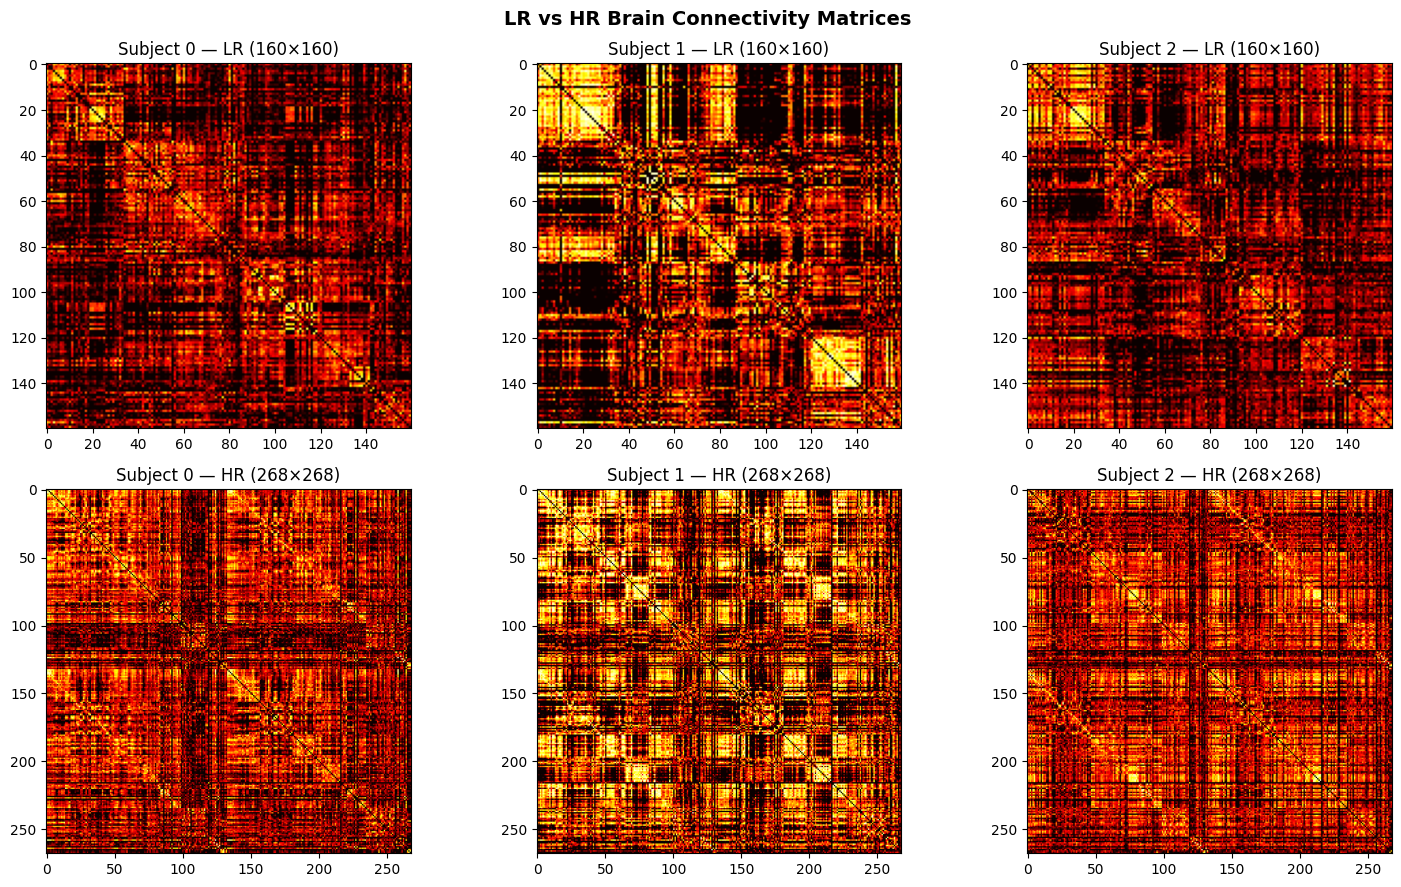

In [5]:
lr_mat0 = MatrixVectorizer.anti_vectorize(lr_train[0], N_LR)
hr_mat0 = MatrixVectorizer.anti_vectorize(hr_train[0], N_HR)
print(f'LR[0]: symmetric={np.allclose(lr_mat0, lr_mat0.T)}  range=[{lr_mat0.min():.3f}, {lr_mat0.max():.3f}]')
print(f'HR[0]: symmetric={np.allclose(hr_mat0, hr_mat0.T)}  range=[{hr_mat0.min():.3f}, {hr_mat0.max():.3f}]')

hr_nonzero_pct = (hr_train > 0).mean() * 100
print(f'HR non-zero edges: {hr_nonzero_pct:.1f}%  (zero: {100-hr_nonzero_pct:.1f}%)')
print(f'HR mean (non-zero only): {hr_train[hr_train > 0].mean():.4f}')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i in range(3):
    lm = MatrixVectorizer.anti_vectorize(lr_train[i], N_LR)
    hm = MatrixVectorizer.anti_vectorize(hr_train[i], N_HR)
    axes[0, i].imshow(lm, cmap='hot', vmin=0, vmax=1)
    axes[0, i].set_title(f'Subject {i} — LR (160×160)')
    axes[1, i].imshow(hm, cmap='hot', vmin=0, vmax=1)
    axes[1, i].set_title(f'Subject {i} — HR (268×268)')
plt.suptitle('LR vs HR Brain Connectivity Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Helper Functions

In [6]:
def anti_vectorize_batch(vectors, N):
    return np.stack([MatrixVectorizer.anti_vectorize(v, N) for v in vectors])

def vectorize_batch(matrices):
    return np.stack([MatrixVectorizer.vectorize(m) for m in matrices])

def postprocess(pred_matrices):
    pred_matrices = np.clip(pred_matrices, 0, None)
    for i in range(len(pred_matrices)):
        np.fill_diagonal(pred_matrices[i], 0)
        pred_matrices[i] = (pred_matrices[i] + pred_matrices[i].T) / 2
    return pred_matrices

THRESHOLD = 0.1

def adj_to_pyg(adj, threshold=THRESHOLD):
    rows, cols = np.where(adj > threshold)
    edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    edge_weight = torch.tensor(adj[rows, cols], dtype=torch.float32)
    return edge_index, edge_weight

## 7. Model Definition (DEFEND-SR)

In [ ]:
class EfficientLineGraphConv(nn.Module):
    """Line-graph message passing WITHOUT building the huge dual adjacency."""

    def __init__(self, in_dim, out_dim, n_nodes, row_idx, col_idx):
        super().__init__()
        self.register_buffer('row_idx', row_idx)
        self.register_buffer('col_idx', col_idx)
        self.n_nodes = n_nodes
        self.W_self = nn.Linear(in_dim, out_dim)
        self.W_neigh = nn.Linear(in_dim, out_dim)

    def forward(self, edge_feat):
        E, d = edge_feat.shape
        node_pool = torch.zeros(self.n_nodes, d, device=edge_feat.device)
        node_pool.scatter_add_(0, self.row_idx.unsqueeze(1).expand(E, d), edge_feat)
        node_pool.scatter_add_(0, self.col_idx.unsqueeze(1).expand(E, d), edge_feat)
        neigh_msg = node_pool[self.row_idx] + node_pool[self.col_idx] - 2 * edge_feat
        return self.W_self(edge_feat) + self.W_neigh(neigh_msg)


class DualGraphRefinement(nn.Module):
    def __init__(self, n_hr, row_idx, col_idx, edge_dim=32, n_layers=3):
        super().__init__()
        self.encoder = nn.Linear(1, edge_dim)
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(EfficientLineGraphConv(
                edge_dim, edge_dim, n_hr, row_idx, col_idx))
            self.norms.append(nn.LayerNorm(edge_dim))
        self.decoder = nn.Sequential(
            nn.Linear(edge_dim, edge_dim),
            nn.ReLU(),
            nn.Linear(edge_dim, 1),
        )

    def forward(self, edge_vec):
        h = self.encoder(edge_vec.unsqueeze(-1))
        for lgc, norm in zip(self.layers, self.norms):
            h = h + F.elu(norm(lgc(h)))
        return self.decoder(h).squeeze(-1)


def sgc_precompute(adj, K=2):
    """Simple Graph Convolution: Â^K where Â = D^{-1/2}(A+I)D^{-1/2}"""
    A = adj + np.eye(adj.shape[0])
    D = np.diag(np.sum(A, axis=1) ** -0.5)
    A_hat = D @ A @ D
    out = A_hat
    for _ in range(K - 1):
        out = out @ A_hat
    # Node features = propagated adjacency rows
    return (out @ adj).astype(np.float32)


class DEFENDSRModel(nn.Module):
    """
    SGC + Low-rank linear + Dual graph refinement.
    """

    def __init__(self, n_lr=N_LR, n_hr=N_HR,
                 sgc_feat_dim=None, edge_dim=32, dual_layers=3, dropout=0.3,
                 **kwargs):  # accept extra kwargs silently
        super().__init__()
        if sgc_feat_dim is None:
            sgc_feat_dim = n_lr  # after SGC, features are (n_lr, n_lr)

        # Branch A: Low-rank linear (LR vec → HR vec)
        rank = 256
        self.linear_down = nn.Linear(N_LR_VEC, rank, bias=False)
        self.linear_up = nn.Linear(rank, N_HR_VEC, bias=True)

        # Branch B: SGC features → flatten → low-rank → HR vec
        sgc_flat = n_lr * sgc_feat_dim   # 160 * 160 = 25600
        self.sgc_down = nn.Linear(sgc_flat, 256, bias=False)
        self.sgc_up = nn.Linear(256, N_HR_VEC, bias=True)

        # Mixing
        self.branch_mix = nn.Parameter(torch.tensor(0.5))

        # Dual graph refinement
        self.dual_refine = DualGraphRefinement(
            n_hr, HR_ROWS, HR_COLS,
            edge_dim=edge_dim, n_layers=dual_layers)
        self.alpha = nn.Parameter(torch.tensor(0.0))

        self.dropout = nn.Dropout(dropout)

    def forward(self, sgc_features, lr_vec):
        """
        sgc_features: (n_lr, n_lr) — precomputed SGC features
        lr_vec:       (N_LR_VEC,)  — upper-tri LR edge vector
        """
        # Branch A: Linear
        linear_pred = self.linear_up(F.relu(self.linear_down(lr_vec)))

        # Branch B: SGC
        sgc_flat = sgc_features.reshape(1, -1).squeeze(0)   # (25600,)
        sgc_pred = self.sgc_up(F.relu(self.dropout(self.sgc_down(sgc_flat))))

        # Combine
        w = torch.sigmoid(self.branch_mix)
        combined = (1 - w) * linear_pred + w * sgc_pred

        # Dual graph refinement
        init_pred = torch.sigmoid(combined)
        delta = self.dual_refine(init_pred)
        mix = torch.sigmoid(self.alpha)
        out = torch.clamp(init_pred + mix * delta, 0.0, 1.0)

        return out

## 8. Loss Functions

In [ ]:
def degree_distribution_loss(pred_vec, gt_vec, n=N_HR, row_idx=None, col_idx=None):
    if row_idx is None:
        row_idx = HR_ROWS.to(pred_vec.device)
        col_idx = HR_COLS.to(pred_vec.device)

    pred_deg = torch.zeros(n, device=pred_vec.device)
    pred_deg.scatter_add_(0, row_idx, pred_vec)
    pred_deg.scatter_add_(0, col_idx, pred_vec)

    gt_deg = torch.zeros(n, device=gt_vec.device)
    gt_deg.scatter_add_(0, row_idx, gt_vec)
    gt_deg.scatter_add_(0, col_idx, gt_vec)

    return F.l1_loss(pred_deg, gt_deg)


def combined_loss(pred, target, lambda_topo=0.02):
    """L1 + MSE + topology loss, covers both average and large errors."""
    l1 = F.l1_loss(pred, target)
    mse = F.mse_loss(pred, target)
    topo = degree_distribution_loss(pred, target)
    return 0.5 * l1 + 0.5 * mse + lambda_topo * topo

## 9. Training Utilities

In [10]:
def train_one_epoch(model, optimizer, sgc_features_list, lr_vecs, hr_vectors,
                    device, epoch, lambda_topo=0.01, batch_size=16):
    model.train()
    n = len(lr_vecs)
    perm = np.random.permutation(n)
    total_loss = 0.0
    total_mae = 0.0

    for start in range(0, n, batch_size):
        batch_idx = perm[start:start+batch_size]
        optimizer.zero_grad()
        batch_loss = 0.0
        batch_mae = 0.0

        for idx in batch_idx:
            sgc_feat = torch.tensor(sgc_features_list[idx], dtype=torch.float32).to(device)
            lr_vec = torch.tensor(lr_vecs[idx], dtype=torch.float32).to(device)
            hr_target = torch.tensor(hr_vectors[idx], dtype=torch.float32).to(device)

            pred = model(sgc_feat, lr_vec)

            loss_mae = F.l1_loss(pred, hr_target)
            loss_topo = degree_distribution_loss(pred, hr_target)
            loss = loss_mae + lambda_topo * loss_topo

            loss.backward()
            batch_loss += loss.item()
            batch_mae += loss_mae.item()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += batch_loss
        total_mae += batch_mae

    return total_loss / n, total_mae / n


@torch.no_grad()
def predict_batch(model, sgc_features_list, lr_vecs, device):
    model.eval()
    preds = []
    for i in range(len(lr_vecs)):
        sgc_feat = torch.tensor(sgc_features_list[i], dtype=torch.float32).to(device)
        lr_vec = torch.tensor(lr_vecs[i], dtype=torch.float32).to(device)
        pred = model(sgc_feat, lr_vec)
        preds.append(pred.cpu().numpy())
    return np.stack(preds)

## 10. Evaluation Metrics (8 measures)

In [11]:
def compute_all_metrics(pred_vecs, gt_vecs, n_hr=N_HR):
    num_samples = len(pred_vecs)

    pred_mats = anti_vectorize_batch(pred_vecs, n_hr)
    gt_mats   = anti_vectorize_batch(gt_vecs, n_hr)
    pred_mats = postprocess(pred_mats)

    mae_bc, mae_ec, mae_pc = [], [], []
    mae_cc, mae_clust = [], []

    for i in range(num_samples):
        pg = nx.from_numpy_array(pred_mats[i], edge_attr='weight')
        gg = nx.from_numpy_array(gt_mats[i],   edge_attr='weight')

        p_bc = list(nx.betweenness_centrality(pg, weight='weight').values())
        g_bc = list(nx.betweenness_centrality(gg, weight='weight').values())
        mae_bc.append(mean_absolute_error(p_bc, g_bc))

        try:
            p_ec = list(nx.eigenvector_centrality(pg, weight='weight', max_iter=500).values())
        except nx.PowerIterationFailedConvergence:
            p_ec = [0.0] * n_hr
        try:
            g_ec = list(nx.eigenvector_centrality(gg, weight='weight', max_iter=500).values())
        except nx.PowerIterationFailedConvergence:
            g_ec = [0.0] * n_hr
        mae_ec.append(mean_absolute_error(p_ec, g_ec))

        p_pc = list(nx.pagerank(pg, weight='weight').values())
        g_pc = list(nx.pagerank(gg, weight='weight').values())
        mae_pc.append(mean_absolute_error(p_pc, g_pc))

        p_cc = list(nx.closeness_centrality(pg, distance=None).values())
        g_cc = list(nx.closeness_centrality(gg, distance=None).values())
        mae_cc.append(mean_absolute_error(p_cc, g_cc))

        p_cl = list(nx.clustering(pg, weight='weight').values())
        g_cl = list(nx.clustering(gg, weight='weight').values())
        mae_clust.append(mean_absolute_error(p_cl, g_cl))

    pred_vecs_pp = vectorize_batch(pred_mats)
    pred_flat = pred_vecs_pp.flatten()
    gt_flat   = gt_vecs.flatten()

    mae_val = mean_absolute_error(pred_flat, gt_flat)
    pcc_val = pearsonr(pred_flat, gt_flat)[0]
    jsd_val = jensenshannon(pred_flat + 1e-12, gt_flat + 1e-12)

    return {
        'MAE':       mae_val,
        'PCC':       pcc_val,
        'JSD':       jsd_val,
        'MAE_PC':    np.mean(mae_pc),
        'MAE_EC':    np.mean(mae_ec),
        'MAE_BC':    np.mean(mae_bc),
        'MAE_CC':    np.mean(mae_cc),
        'MAE_Clust': np.mean(mae_clust),
    }

## 11. Plotting Utilities

In [12]:
METRIC_NAMES = ['MAE', 'PCC', 'JSD', 'MAE_PC', 'MAE_EC', 'MAE_BC', 'MAE_CC', 'MAE_Clust']
METRIC_LABELS = ['MAE', 'PCC', 'JSD', 'MAE(PC)', 'MAE(EC)', 'MAE(BC)', 'MAE(CC)', 'MAE(Clust)']

def plot_fold_bars(all_fold_metrics, save_path='cv_barplots.png'):
    n_folds = len(all_fold_metrics)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12',
              '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

    for f_idx in range(n_folds):
        ax = axes[f_idx]
        vals = [all_fold_metrics[f_idx][k] for k in METRIC_NAMES]
        bars = ax.bar(METRIC_LABELS, vals, color=colors)
        ax.set_title(f'Fold {f_idx+1}', fontweight='bold')
        ax.set_ylim(bottom=0)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=7)
        ax.tick_params(axis='x', rotation=45)

    ax = axes[n_folds]
    means, stds = [], []
    for k in METRIC_NAMES:
        fold_vals = [all_fold_metrics[f][k] for f in range(n_folds)]
        means.append(np.mean(fold_vals))
        stds.append(np.std(fold_vals))

    bars = ax.bar(METRIC_LABELS, means, yerr=stds, capsize=4, color=colors)
    ax.set_title('Avg. Across Folds', fontweight='bold')
    ax.set_ylim(bottom=0)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{m:.4f}', ha='center', va='bottom', fontsize=7)
    ax.tick_params(axis='x', rotation=45)

    for idx in range(n_folds + 1, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('DEFEND-SR v2 — 3-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved bar plots to {save_path}')

## 12. Kaggle Submission CSV

In [13]:
def create_submission_csv(pred_vecs, filename):
    melted = pred_vecs.flatten()
    df = pd.DataFrame({
        'ID': np.arange(1, len(melted) + 1),
        'Predicted': melted,
    })
    df.to_csv(filename, index=False)
    print(f'  Saved {filename}  ({len(melted)} entries)')

## 13. 3-Fold Cross-Validation

In [14]:
def run_3fold_cv(
    lr_data, hr_data, lr_test_data,
    edge_dim=32, dual_layers=3, dropout=0.3,
    epochs=80, lr=1e-3, weight_decay=5e-4,
    lambda_topo=0.01, patience=60,
    n_folds=3, random_state=42, **kwargs,
):
    print('\n' + '='*70)
    print('  DEFEND-SR v4: 3-Fold Cross-Validation')
    print('='*70)

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    lr_matrices_all = anti_vectorize_batch(lr_data, N_LR)

    # Precompute SGC features for all samples
    print('  Precomputing SGC features...')
    sgc_features_all = np.stack([sgc_precompute(m, K=2) for m in lr_matrices_all])
    # LR vectors for linear branch
    lr_vecs_all = lr_data

    all_fold_metrics = []
    start_total = time.time()

    for fold, (train_idx, val_idx) in enumerate(kf.split(lr_data)):
        print(f'\n── Fold {fold+1}/{n_folds} ──')
        t_fold = time.time()

        sgc_train = sgc_features_all[train_idx]
        lr_vecs_train = lr_vecs_all[train_idx]
        hr_train_fold = hr_data[train_idx]

        sgc_val = sgc_features_all[val_idx]
        lr_vecs_val = lr_vecs_all[val_idx]
        hr_val_fold = hr_data[val_idx]

        model = DEFENDSRModel(
            edge_dim=edge_dim, dual_layers=dual_layers, dropout=dropout,
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

        best_val_loss = float('inf')
        best_state = None
        wait = 0

        for ep in range(1, epochs + 1):
            train_loss, train_mae = train_one_epoch(
                model, optimizer, sgc_train, lr_vecs_train, hr_train_fold,
                device, ep, lambda_topo=lambda_topo, batch_size=16,
            )

            scheduler.step()

            if ep % 5 == 0 or ep == epochs:
                model.eval()
                val_preds = predict_batch(model, sgc_val, lr_vecs_val, device)
                val_loss = mean_absolute_error(val_preds.flatten(), hr_val_fold.flatten())

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    wait = 0
                else:
                    wait += 1

                if ep % 10 == 0:
                    mem_mb = psutil.Process().memory_info().rss / 1024**2
                    print(f'  Epoch {ep:3d}  train_MAE={train_mae:.5f}  '
                          f'val_MAE={val_loss:.5f}  gap={train_mae-val_loss:+.5f}  '
                          f'best={best_val_loss:.5f}  RAM={mem_mb:.0f}MB')

                if wait >= patience:
                    print(f'  Early stopping at epoch {ep}.')
                    break

        model.load_state_dict(best_state)
        model.to(device)

        val_preds = predict_batch(model, sgc_val, lr_vecs_val, device)
        val_preds = np.clip(val_preds, 0, None)

        metrics = compute_all_metrics(val_preds, hr_val_fold, N_HR)
        all_fold_metrics.append(metrics)

        print(f'  Fold {fold+1} results:')
        for k, v in metrics.items():
            print(f'    {k}: {v:.6f}')
        print(f'  Fold time: {time.time()-t_fold:.1f}s')

        create_submission_csv(val_preds, f'predictions_fold_{fold+1}.csv')

        del model, optimizer, scheduler
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()

    total_time = time.time() - start_total
    mem_mb = psutil.Process().memory_info().rss / 1024**2
    print(f'\nTotal 3F-CV time: {total_time:.1f}s   RAM: {mem_mb:.0f}MB')

    plot_fold_bars(all_fold_metrics, save_path='cv_barplots.png')

    print('\n── Average across folds ──')
    for k in METRIC_NAMES:
        vals = [m[k] for m in all_fold_metrics]
        print(f'  {k}: {np.mean(vals):.6f} ± {np.std(vals):.6f}')

    return all_fold_metrics

## 14. Full Training + Test Prediction (for Kaggle)

In [22]:
def train_full_and_predict_test(
    lr_data, hr_data, lr_test_data,
    edge_dim=32, dual_layers=3, dropout=0.40,
    epochs=55, lr=1e-3, weight_decay=1e-3,
    lambda_topo=0.01, n_ensemble=9, **kwargs,
):
    print('\n' + '='*70)
    print(f'  Training ENSEMBLE of {n_ensemble} models → Test predictions')
    print('='*70)

    lr_matrices = anti_vectorize_batch(lr_data, N_LR)
    lr_test_matrices = anti_vectorize_batch(lr_test_data, N_LR)

    print('  Precomputing SGC features...')
    sgc_train = np.stack([sgc_precompute(m, K=2) for m in lr_matrices])
    sgc_test = np.stack([sgc_precompute(m, K=2) for m in lr_test_matrices])

    all_test_preds = []

    for ens_idx in range(n_ensemble):
        seed = random_seed + ens_idx * 7
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        print(f'\n── Model {ens_idx+1}/{n_ensemble} (seed={seed}) ──')

        model = DEFENDSRModel(
            edge_dim=edge_dim, dual_layers=dual_layers, dropout=dropout,
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

        for ep in range(1, epochs + 1):
            loss, train_mae = train_one_epoch(
                model, optimizer, sgc_train, lr_data, hr_data,
                device, ep, lambda_topo=lambda_topo, batch_size=16)
            scheduler.step()
            if ep % 20 == 0:
                print(f'    Epoch {ep:3d}  train_MAE={train_mae:.5f}')

        test_preds = predict_batch(model, sgc_test, lr_test_data, device)
        test_preds = np.clip(test_preds, 0, None)
        all_test_preds.append(test_preds)

        del model, optimizer, scheduler
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()

    avg_preds = np.mean(all_test_preds, axis=0)
    avg_preds = np.clip(avg_preds, 0, None)
    
    hr_mean = hr_data.mean(axis=0)
    blend_alpha = 0.05
    avg_preds = (1 - blend_alpha) * avg_preds + blend_alpha * hr_mean
    avg_preds = np.clip(avg_preds, 0, None)

    create_submission_csv(avg_preds, 'submission.csv')

    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)

    return avg_preds

## 15. Run Everything


  DEFEND-SR v4: 3-Fold Cross-Validation
  Precomputing SGC features...

── Fold 1/3 ──
  Epoch  10  train_MAE=0.14167  val_MAE=0.13608  gap=+0.00559  best=0.13608  RAM=1919MB
  Epoch  20  train_MAE=0.13319  val_MAE=0.13198  gap=+0.00120  best=0.13198  RAM=1919MB
  Epoch  30  train_MAE=0.13358  val_MAE=0.13083  gap=+0.00276  best=0.13082  RAM=1944MB
  Epoch  40  train_MAE=0.12705  val_MAE=0.12842  gap=-0.00137  best=0.12842  RAM=1944MB
  Epoch  50  train_MAE=0.12401  val_MAE=0.12767  gap=-0.00366  best=0.12767  RAM=1942MB
  Epoch  60  train_MAE=0.12269  val_MAE=0.12670  gap=-0.00401  best=0.12670  RAM=1967MB
  Epoch  70  train_MAE=0.12082  val_MAE=0.12603  gap=-0.00521  best=0.12601  RAM=1898MB
  Epoch  80  train_MAE=0.11972  val_MAE=0.12545  gap=-0.00573  best=0.12545  RAM=1922MB
  Fold 1 results:
    MAE: 0.125448
    PCC: 0.691014
    JSD: 0.269778
    MAE_PC: 0.000501
    MAE_EC: 0.011726
    MAE_BC: 0.022301
    MAE_CC: 0.124159
    MAE_Clust: 0.057536
  Fold time: 961.8s
  Saved 

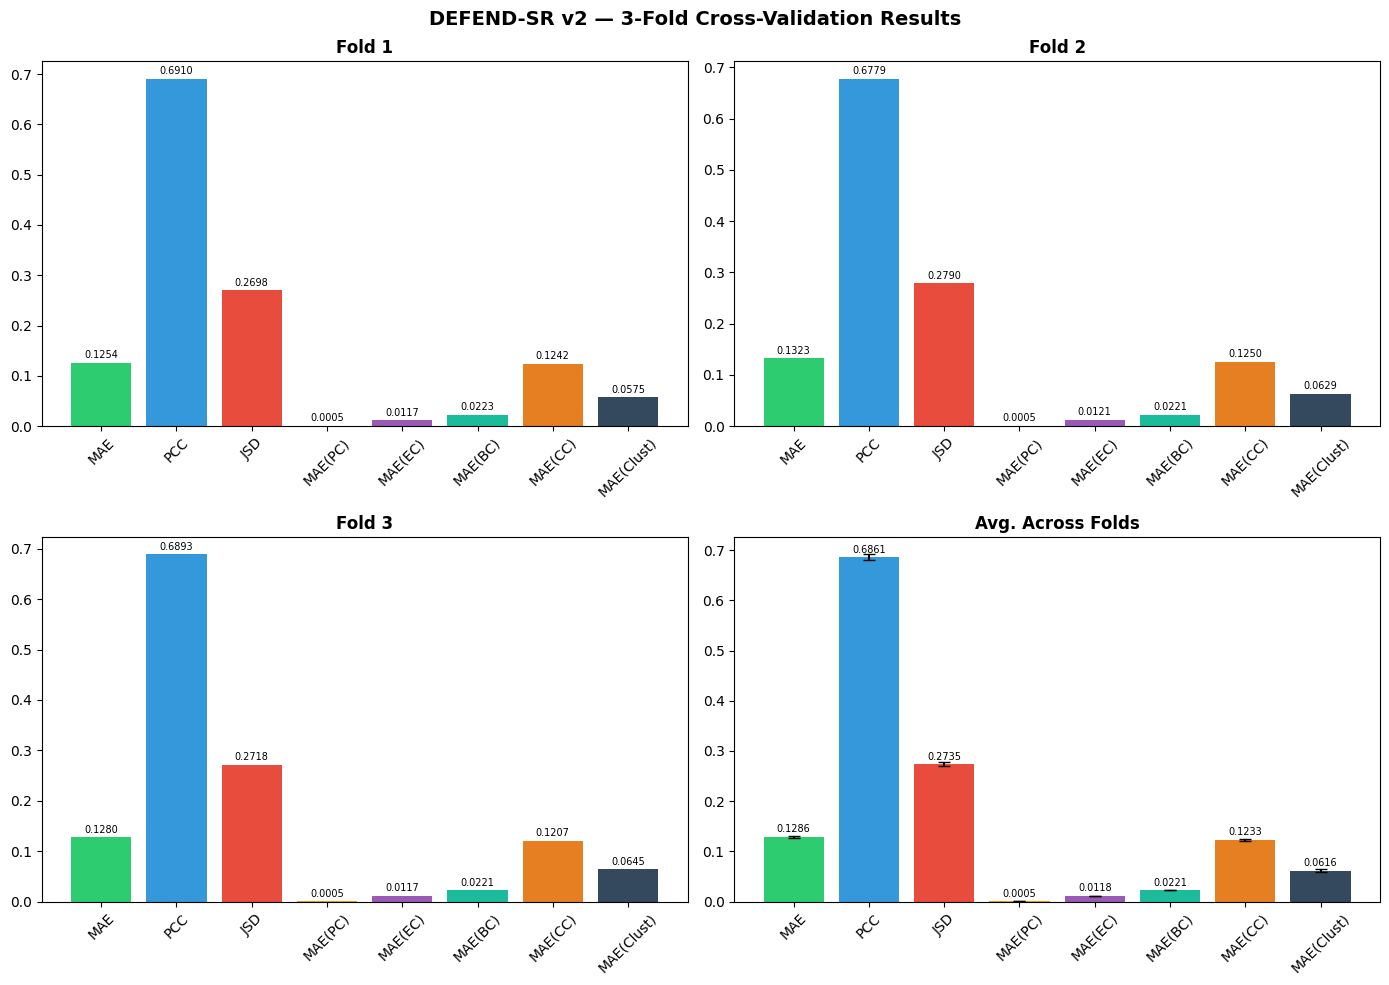

Saved bar plots to cv_barplots.png

── Average across folds ──
  MAE: 0.128579 ± 0.002828
  PCC: 0.686091 ± 0.005819
  JSD: 0.273522 ± 0.003944
  MAE_PC: 0.000506 ± 0.000004
  MAE_EC: 0.011823 ± 0.000191
  MAE_BC: 0.022145 ± 0.000111
  MAE_CC: 0.123272 ± 0.001881
  MAE_Clust: 0.061649 ± 0.002979


In [16]:
HPARAMS = dict(
    edge_dim=32,
    dual_layers=3,
    dropout=0.25,
    epochs=80,
    lr=1e-3,
    weight_decay=5e-4,
    lambda_topo=0.01,
    patience=60,
)

fold_metrics = run_3fold_cv(
    lr_train, hr_train, lr_test,
    n_folds=3, random_state=random_seed,
    **HPARAMS,
)

In [23]:
test_preds = train_full_and_predict_test(
    lr_train, hr_train, lr_test,
    edge_dim=HPARAMS['edge_dim'],
    dual_layers=HPARAMS['dual_layers'],
    dropout=0.40,
    epochs=55,
    lr=HPARAMS['lr'],
    weight_decay=1e-3,
    lambda_topo=HPARAMS['lambda_topo'],
    n_ensemble=7,
)


  Training ENSEMBLE of 7 models → Test predictions
  Precomputing SGC features...

── Model 1/7 (seed=42) ──
    Epoch  20  train_MAE=0.13306
    Epoch  40  train_MAE=0.12892

── Model 2/7 (seed=49) ──
    Epoch  20  train_MAE=0.13808
    Epoch  40  train_MAE=0.13337

── Model 3/7 (seed=56) ──
    Epoch  20  train_MAE=0.13854
    Epoch  40  train_MAE=0.13082

── Model 4/7 (seed=63) ──
    Epoch  20  train_MAE=0.13509
    Epoch  40  train_MAE=0.13096

── Model 5/7 (seed=70) ──
    Epoch  20  train_MAE=0.13674
    Epoch  40  train_MAE=0.13082

── Model 6/7 (seed=77) ──
    Epoch  20  train_MAE=0.13558
    Epoch  40  train_MAE=0.13101

── Model 7/7 (seed=84) ──
    Epoch  20  train_MAE=0.13584
    Epoch  40  train_MAE=0.13304
  Saved submission.csv  (4007136 entries)
